# Thesis Figure 7 Ã¢â‚¬â€ Method Comparison on ImageNet-S

Produces one row per image, columns:
**original | CIAO regions (UCB) | CIAO saliency | LIME | MP | Occlusion | GradCAM++**

Edit only the **Configuration** cell.

In [1]:
import json
import os
import re
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from mlflow.tracking import MlflowClient


REPO_ROOT = Path("../..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from ciao.data.preprocessing import load_and_preprocess_image
from ciao.metrics import build_saliency_map
from ciao.visualization.visualization import _to_hwc


# Ã¢â€â‚¬Ã¢â€â‚¬ MLflow Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
TRACKING_URI = "https://mlflow.rationai.cloud.e-infra.cz/"
CIAO_EXPERIMENT = "algorithm-comparison-imagenet-s"
BASELINES_EXPERIMENT = "baselines-comparison-imagenet-s"
os.environ["MLFLOW_TRACKING_USERNAME"] = "YOUR_MLFLOW_USERNAME"
os.environ["MLFLOW_TRACKING_PASSWORD"] = "YOUR_MLFLOW_PASSWORD"

# Ã¢â€â‚¬Ã¢â€â‚¬ Images to visualize Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
IMAGES = [
    "imagenets_0054.jpg",
    "imagenets_0098.jpg",
    "imagenets_0112.jpg",
    "imagenets_0117.jpg",
]
LOCAL_IMAGES_PATH = Path("REPO_ROOT/images/images")

# Ã¢â€â‚¬Ã¢â€â‚¬ CIAO settings Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
DESIRED_LENGTH_CIAO = 60  # change after viewing the regions column
ALL_DESIRED_LENGTHS = [15, 30, 60, 90]
SIGMA_FRACTION = 0.03  # Gaussian sigma = fraction of shorter image side

# Ã¢â€â‚¬Ã¢â€â‚¬ Baseline column order Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
BASELINE_METHODS = ["lime-slic", "occlusion", "gradcampp"]

# Ã¢â€â‚¬Ã¢â€â‚¬ Output Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
OUTPUT_DIR = Path("output/07_comparison_imagenet")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
mlflow.set_tracking_uri(TRACKING_URI)
client = MlflowClient(tracking_uri=TRACKING_URI)
_name_re = re.compile(r"^(?P<label>.+)-(?P<seed>\d+)-length-(?P<length>\d+)$")


def _load_experiment_runs(exp_name: str) -> pd.DataFrame:
    exp = mlflow.get_experiment_by_name(exp_name)
    if exp is None:
        raise RuntimeError(f"Experiment '{exp_name}' not found")
    return mlflow.search_runs(
        experiment_ids=[exp.experiment_id], output_format="pandas"
    )


def _npy(run_id: str, name: str) -> np.ndarray | None:
    try:
        with tempfile.TemporaryDirectory() as d:
            p = client.download_artifacts(run_id, name, dst_path=d)
            return np.load(p)
    except Exception:
        return None


def _json_art(run_id: str, path: str) -> dict | None:
    try:
        with tempfile.TemporaryDirectory() as d:
            p = client.download_artifacts(run_id, path, dst_path=d)
            with open(p) as f:
                return json.load(f)
    except Exception:
        return None


def _png(run_id: str, path: str) -> np.ndarray | None:
    try:
        with tempfile.TemporaryDirectory() as d:
            p = client.download_artifacts(run_id, path, dst_path=d)
            return plt.imread(p)
    except Exception:
        return None


def _region_segments(run_id: str) -> list[list[int]]:
    regions, idx = [], 0
    while True:
        d = _json_art(run_id, f"region_{idx}/segments.json")
        if d is None:
            break
        regions.append(d["segments"])
        idx += 1
    return regions


def _binary_mask(segs: np.ndarray, ids: list[int]) -> np.ndarray:
    m = np.zeros(segs.shape, dtype=bool)
    for s in ids:
        m |= segs == s
    return m


def _red_overlay(img: np.ndarray, mask: np.ndarray, alpha: float = 0.5) -> np.ndarray:
    out = img.copy()
    out[mask] = out[mask] * (1 - alpha) + np.array([1.0, 0.0, 0.0]) * alpha
    return out


def _save_single(img_np: np.ndarray, path: Path, dpi: int = 150) -> None:
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.imshow(img_np, interpolation="nearest")
    ax.axis("off")
    fig.tight_layout(pad=0)
    fig.savefig(path, dpi=dpi, bbox_inches="tight", pad_inches=0)
    fig.savefig(path.with_suffix(".pdf"), dpi=dpi, bbox_inches="tight", pad_inches=0)
    plt.close(fig)


def _saliency_overlay(
    img: np.ndarray, sal: np.ndarray, path: Path, dpi: int = 150
) -> None:
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.imshow(img, interpolation="nearest")
    ax.imshow(sal, cmap="jet", alpha=0.5, vmin=0.0, vmax=1.0)
    ax.axis("off")
    fig.tight_layout(pad=0)
    fig.savefig(path, dpi=dpi, bbox_inches="tight", pad_inches=0)
    fig.savefig(path.with_suffix(".pdf"), dpi=dpi, bbox_inches="tight", pad_inches=0)
    plt.close(fig)

In [3]:
print("Loading CIAO (UCB) runs Ã¢â‚¬Â¦")
ciao_all = _load_experiment_runs(CIAO_EXPERIMENT)
parents = ciao_all[ciao_all["tags.mlflow.parentRunId"].isna()].copy()
children = ciao_all[ciao_all["tags.mlflow.parentRunId"].notna()].copy()


def _parse(name):
    m = _name_re.match(str(name) if isinstance(name, str) else "")
    if not m:
        return None, None, None
    return m.group("label"), int(m.group("seed")), int(m.group("length"))


_p = parents["tags.mlflow.runName"].apply(_parse)
parents = parents.assign(
    label=_p.apply(lambda x: x[0]),
    seed=_p.apply(lambda x: x[1]),
    desired_length=_p.apply(lambda x: x[2]),
)

ciao_data = children.merge(
    parents[["run_id", "label", "seed", "desired_length"]].dropna(subset=["label"]),
    left_on="tags.mlflow.parentRunId",
    right_on="run_id",
    suffixes=("", "_parent"),
    how="inner",
)
ciao_data["image_name"] = ciao_data["tags.mlflow.runName"]
ciao_data["desired_length"] = ciao_data["desired_length"].astype(int)
ucb = ciao_data[ciao_data["label"] == "ucb"].copy()

# {image_name: {length: run_id}}
ucb_lookup: dict[str, dict[int, str]] = {}
for _, r in ucb.iterrows():
    ucb_lookup.setdefault(r["image_name"], {})[r["desired_length"]] = r["run_id"]

print(f"UCB child runs: {len(ucb)}")
for img in IMAGES:
    print(f"  {img}: lengths = {sorted(ucb_lookup.get(img, {}).keys())}")

Loading CIAO (UCB) runs Ã¢â‚¬Â¦
UCB child runs: 400
  imagenets_0054.jpg: lengths = [15, 30, 60, 90]
  imagenets_0098.jpg: lengths = [15, 30, 60, 90]
  imagenets_0112.jpg: lengths = [15, 30, 60, 90]
  imagenets_0117.jpg: lengths = [15, 30, 60, 90]


In [4]:
print("Loading baseline runs Ã¢â‚¬Â¦")
bl_all = _load_experiment_runs(BASELINES_EXPERIMENT)
bl_parents = bl_all[bl_all["tags.mlflow.parentRunId"].isna()].copy()
bl_children = bl_all[bl_all["tags.mlflow.parentRunId"].notna()].copy()
bl_parents["label"] = bl_parents["tags.mlflow.runName"]

if len(bl_children):
    bl_data = bl_children.merge(
        bl_parents[["run_id", "label"]],
        left_on="tags.mlflow.parentRunId",
        right_on="run_id",
        suffixes=("", "_parent"),
        how="inner",
    )
    bl_data["image_name"] = bl_data["tags.mlflow.runName"]
else:
    bl_data = bl_parents.copy()
    bl_data["image_name"] = bl_data["tags.mlflow.runName"]

print(f"Baseline labels: {sorted(bl_data['label'].unique())}")

# {method: {image_name: run_id}}
bl_lookup: dict[str, dict[str, str]] = {}
for _, r in bl_data.iterrows():
    bl_lookup.setdefault(r["label"], {})[r["image_name"]] = r["run_id"]

Loading baseline runs Ã¢â‚¬Â¦
Baseline labels: ['gradcampp', 'lime-slic', 'mp', 'occlusion']


In [5]:
_orig_col = next(
    (c for c in ["metrics.region_0/original_prob"] if c in ucb.columns), None
)
_drop_col = next(
    (
        c
        for c in [
            "metrics.all_regions/probability_drop",
            "metrics.region_0/probability_drop",
        ]
        if c in ucb.columns
    ),
    None,
)
_iou_col = next((c for c in ["metrics.iou"] if c in ucb.columns), None)
_cls_col = next((c for c in ["params.class_name"] if c in ucb.columns), None)

rows = []
for img in IMAGES:
    for length in ALL_DESIRED_LENGTHS:
        rid = ucb_lookup.get(img, {}).get(length)
        if rid is None:
            continue
        r = ucb[ucb["run_id"] == rid].iloc[0]
        rows.append(
            {
                "image": img,
                "length": length,
                "class": r[_cls_col] if _cls_col else "?",
                "orig_prob": round(float(r[_orig_col]), 3) if _orig_col else None,
                "prob_drop": round(float(r[_drop_col]), 3) if _drop_col else None,
                "iou": round(float(r[_iou_col]), 3) if _iou_col else None,
            }
        )

display(pd.DataFrame(rows))

,image,length,class,orig_prob,prob_drop,iou
0,imagenets_0054.jpg,15,wood rabbit,0.980,0.278,0.407
1,imagenets_0054.jpg,30,wood rabbit,0.980,0.339,0.407
2,imagenets_0054.jpg,60,wood rabbit,0.980,0.976,0.407
3,imagenets_0054.jpg,90,wood rabbit,0.980,0.979,0.407
4,imagenets_0098.jpg,15,fly,0.957,0.939,0.000
5,imagenets_0098.jpg,30,fly,0.957,0.957,0.000
6,imagenets_0098.jpg,60,fly,0.957,0.957,0.000
7,imagenets_0098.jpg,90,fly,0.957,0.957,0.000
8,imagenets_0112.jpg,15,beagle,0.280,0.275,0.000
9,imagenets_0112.jpg,30,beagle,0.280,0.278,0.000


In [6]:
device = torch.device("cpu")
orig_imgs: dict[str, np.ndarray] = {}
saliency_maps: dict[str, np.ndarray | None] = {}
region_overlays: dict[str, np.ndarray | None] = {}

for img_name in IMAGES:
    print(f"\n{img_name}")
    img_tensor = load_and_preprocess_image(LOCAL_IMAGES_PATH / img_name, device=device)
    img_np = _to_hwc(img_tensor.unsqueeze(0))
    orig_imgs[img_name] = img_np

    # Saliency map Ã¢â‚¬â€ union of all regions across all desired lengths
    binary_masks = []
    for length in ALL_DESIRED_LENGTHS:
        rid = ucb_lookup.get(img_name, {}).get(length)
        if rid is None:
            print(f"  skip length={length}: no run")
            continue
        segs = _npy(rid, "segments.npy")
        if segs is None:
            print(f"  skip length={length}: segments.npy missing")
            continue
        reg_segs = _region_segments(rid)
        if not reg_segs:
            print(f"  skip length={length}: no region segments")
            continue
        all_ids = [s for reg in reg_segs for s in reg]
        binary_masks.append(_binary_mask(segs, all_ids))
        print(f"  length={length}: {len(reg_segs)} regions, {len(all_ids)} segs")

    saliency_maps[img_name] = (
        build_saliency_map(binary_masks, sigma_fraction=SIGMA_FRACTION)
        if binary_masks
        else None
    )

    # Region overlay at DESIRED_LENGTH_CIAO
    rid_dl = ucb_lookup.get(img_name, {}).get(DESIRED_LENGTH_CIAO)
    if rid_dl:
        segs = _npy(rid_dl, "segments.npy")
        reg_segs = _region_segments(rid_dl)
        if segs is not None and reg_segs:
            all_ids = [s for reg in reg_segs for s in reg]
            region_overlays[img_name] = _red_overlay(
                img_np, _binary_mask(segs, all_ids)
            )
        else:
            region_overlays[img_name] = None
    else:
        region_overlays[img_name] = None

print("\nDone building CIAO artifacts.")


imagenets_0054.jpg


  length=15: 1 regions, 15 segs


  length=30: 1 regions, 30 segs


  length=60: 1 regions, 60 segs


  length=90: 1 regions, 90 segs


...

  length=15: 1 regions, 15 segs


  length=30: 1 regions, 30 segs


  length=60: 1 regions, 60 segs


  length=90: 1 regions, 90 segs



Done building CIAO artifacts.


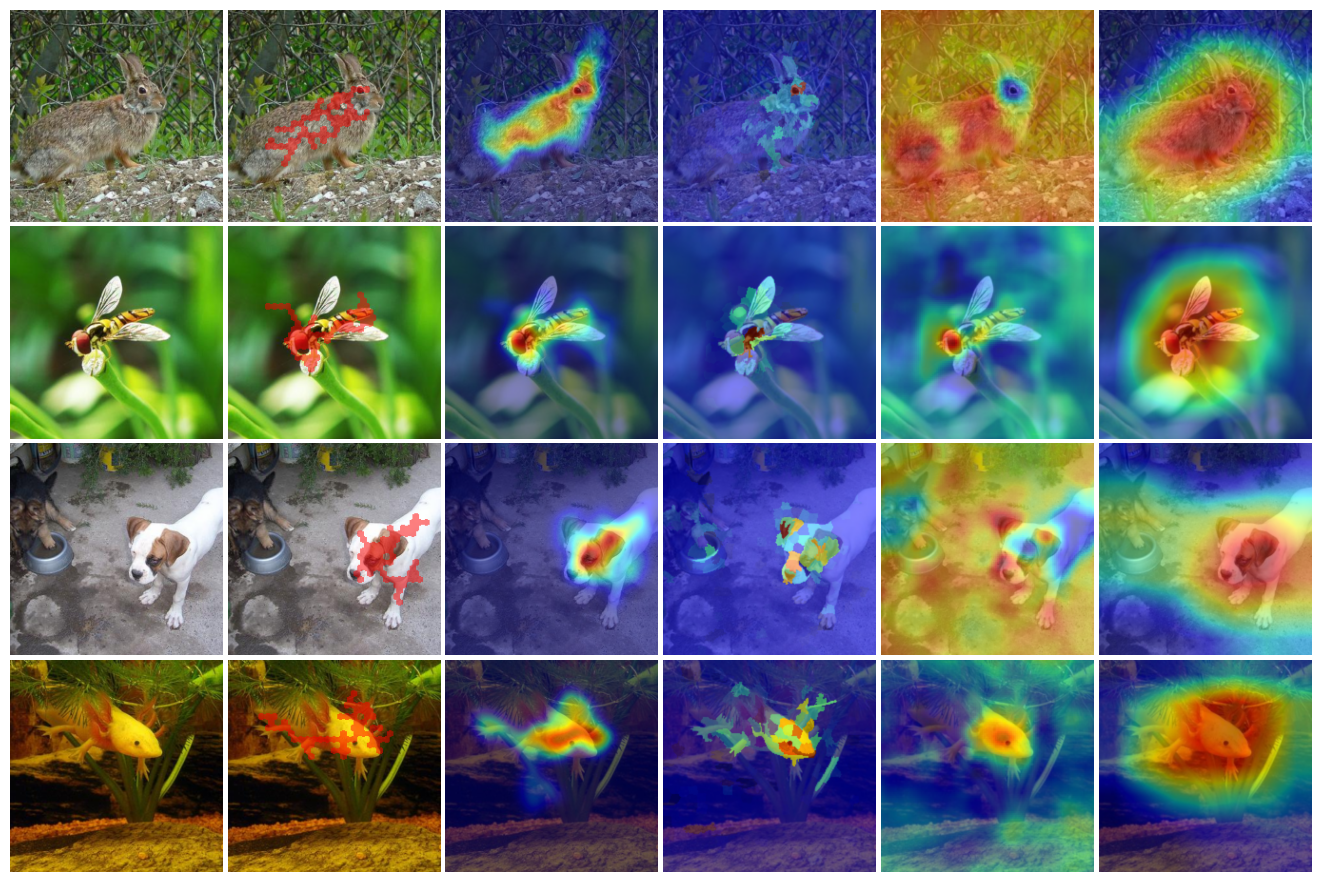

Saved Ã¢â€ â€™ output\07_comparison_imagenet/comparison_grid.png


In [7]:
NCOLS = 3 + len(BASELINE_METHODS)
NROWS = len(IMAGES)
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(2.8 * NCOLS, 2.8 * NROWS))
if NROWS == 1:
    axes = axes[np.newaxis, :]

for ri, img_name in enumerate(IMAGES):

    def _ax(ci):
        ax = axes[ri, ci]
        ax.axis("off")
        return ax

    # col 0: original
    _ax(0).imshow(orig_imgs[img_name])

    # col 1: CIAO selected regions
    ax = _ax(1)
    ov = region_overlays.get(img_name)
    if ov is not None:
        ax.imshow(ov)
    else:
        ax.text(
            0.5,
            0.5,
            "N/A",
            ha="center",
            va="center",
            transform=ax.transAxes,
            color="red",
        )

    # col 2: CIAO saliency map
    ax = _ax(2)
    sal = saliency_maps.get(img_name)
    if sal is not None:
        ax.imshow(orig_imgs[img_name])
        ax.imshow(sal, cmap="jet", alpha=0.5, vmin=0.0, vmax=1.0)
    else:
        ax.text(
            0.5,
            0.5,
            "N/A",
            ha="center",
            va="center",
            transform=ax.transAxes,
            color="red",
        )

    # cols 3+: baselines
    for bi, method in enumerate(BASELINE_METHODS):
        ax = _ax(3 + bi)
        rid = bl_lookup.get(method, {}).get(img_name)
        if rid:
            arr = _png(rid, "figures/heatmap_overlay.png")
            if arr is not None:
                ax.imshow(arr)
            else:
                ax.text(
                    0.5,
                    0.5,
                    "no artifact",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                    color="gray",
                    fontsize=7,
                )
        else:
            ax.text(
                0.5,
                0.5,
                "no run",
                ha="center",
                va="center",
                transform=ax.transAxes,
                color="gray",
                fontsize=7,
            )

fig.subplots_adjust(wspace=0.02, hspace=0.02)
for sfx in [".png", ".pdf"]:
    fig.savefig(
        OUTPUT_DIR / f"comparison_grid{sfx}",
        dpi=150,
        bbox_inches="tight",
        pad_inches=0.02,
    )
plt.show()
print(f"Saved Ã¢â€ â€™ {OUTPUT_DIR}/comparison_grid.png")

In [8]:
for img_name in IMAGES:
    stem = Path(img_name).stem
    img_dir = OUTPUT_DIR / stem
    img_dir.mkdir(parents=True, exist_ok=True)

    _save_single(orig_imgs[img_name], img_dir / "original.png")

    ov = region_overlays.get(img_name)
    if ov is not None:
        _save_single(ov, img_dir / f"ciao_regions_l{DESIRED_LENGTH_CIAO}.png")

    sal = saliency_maps.get(img_name)
    if sal is not None:
        _saliency_overlay(orig_imgs[img_name], sal, img_dir / "ciao_saliency.png")

    for method in BASELINE_METHODS:
        rid = bl_lookup.get(method, {}).get(img_name)
        if rid:
            arr = _png(rid, "figures/heatmap_overlay.png")
            if arr is not None:
                _save_single(arr, img_dir / f"baseline_{method}.png")

print(f"Saved all individual images to {OUTPUT_DIR}/")

Saved all individual images to output\07_comparison_imagenet/
